# UKEA 316 vs UKEA Interface 316 — Comparison

Overlays diffusivity and permeability of `UKEA_316_steel` and `UKEA_interface_316_steel` on the same Arrhenius plots, with weighted log-space fits for each and `h_transport_materials` 316L literature as background.

In [1]:
import sys, os
sys.path.append(os.path.join("..", "ShieldRunsAnalysis"))

import h_transport_materials as htm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from uncertainties import unumpy as unp

from analysis_functions import parse_ufloat

os.makedirs("figs", exist_ok=True)

k_B = 8.617333262e-5  # eV/K

In [2]:
CSV_DIR = os.path.join("..", "ShieldRunsAnalysis", "results", "figs")

materials = {
    "UKEA_316_steel": {
        "csv": os.path.join(CSV_DIR, "UKEA_316_steel_diffusivities.csv"),
        "color": "tab:blue",
        "label": "UKEA 316 steel",
    },
    "UKEA_interface_316_steel": {
        "csv": os.path.join(CSV_DIR, "UKEA_interface_316_steel_diffusivities.csv"),
        "color": "tab:red",
        "label": "UKEA interface 316 steel",
    },
}

In [3]:
def load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["Temperature (K)", "Diffusivity", "Permeability"]:
        df[col] = df[col].apply(parse_ufloat)
    df = df.dropna(subset=["Temperature (K)", "Diffusivity", "Permeability"])

    # Drop physically invalid rows (e.g. failed fits producing non-positive D or Phi),
    # since the Arrhenius fit operates in log space.
    def _nom_pos(v):
        n = v.n if hasattr(v, "n") else v
        return n > 0

    df = df[df["Diffusivity"].apply(_nom_pos) & df["Permeability"].apply(_nom_pos)]

    df = df.sort_values(
        by="Temperature (K)",
        key=lambda s: [v.n if hasattr(v, "n") else v for v in s],
    )
    T = df["Temperature (K)"].to_numpy()
    D = df["Diffusivity"].to_numpy()
    Phi = df["Permeability"].to_numpy()
    return T, D, Phi

In [4]:
def arrhenius_fit(T, y):
    """Weighted linear fit of log(y) vs 1/T. Accepts ufloat or float arrays.
    Returns (coeffs, invT_fit, y_fit, E_a_eV, y0).
    """
    T_nom = unp.nominal_values(T)
    y_log = unp.log(y)
    y_nom = unp.nominal_values(y_log)
    y_std = unp.std_devs(y_log)

    invT = 1.0 / T_nom
    w = np.where((y_std > 0) & np.isfinite(y_std), 1.0 / y_std, 1.0)

    coeffs = np.polyfit(invT, y_nom, 1, w=w)
    slope, intercept = coeffs

    invT_fit = np.linspace(invT.min(), invT.max(), 200)
    y_fit = np.exp(slope * invT_fit + intercept)

    E_a_eV = -slope * k_B
    y0 = np.exp(intercept)
    return coeffs, invT_fit, y_fit, E_a_eV, y0

In [5]:
data = {}
fits = {}
for key, cfg in materials.items():
    T, D, Phi = load(cfg["csv"])
    d_coeffs, d_invT_fit, d_fit, E_D, D0 = arrhenius_fit(T, D)
    p_coeffs, p_invT_fit, p_fit, E_Phi, Phi0 = arrhenius_fit(T, Phi)
    data[key] = {"T": T, "D": D, "Phi": Phi}
    fits[key] = {
        "D": {"invT": d_invT_fit, "y": d_fit, "E_a": E_D, "y0": D0},
        "Phi": {"invT": p_invT_fit, "y": p_fit, "E_a": E_Phi, "y0": Phi0},
    }
    print(f"{key}: {len(T)} points")

UKEA_316_steel: 6 points
UKEA_interface_316_steel: 4 points


/var/folders/7t/tdtw27sn0rv7xkpyj2z631300000gn/T/ipykernel_4823/1475222369.py:11: RuntimeWarning: divide by zero encountered in divide
  w = np.where((y_std > 0) & np.isfinite(y_std), 1.0 / y_std, 1.0)
/var/folders/7t/tdtw27sn0rv7xkpyj2z631300000gn/T/ipykernel_4823/1475222369.py:11: RuntimeWarning: divide by zero encountered in divide
  w = np.where((y_std > 0) & np.isfinite(y_std), 1.0 / y_std, 1.0)


## Diffusivity comparison

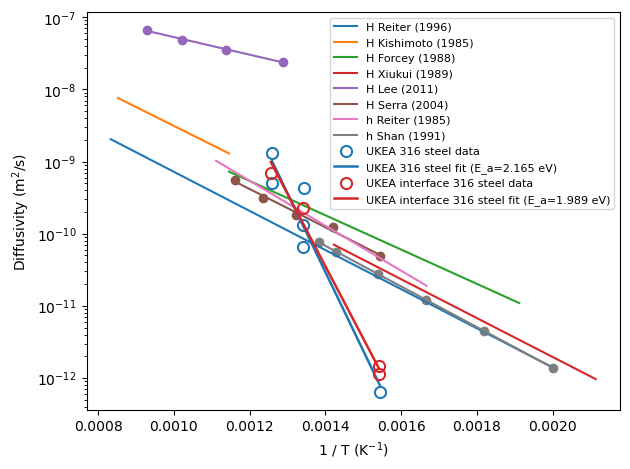

In [6]:
diffusivities = htm.diffusivities.filter(material="316l_steel").filter(isotope="h")
htm.plotting.plot(diffusivities)
ax = plt.gca()

for key, cfg in materials.items():
    T = data[key]["T"]
    D = data[key]["D"]
    invT_nom = 1.0 / unp.nominal_values(T)
    D_nom = unp.nominal_values(D)

    ax.plot(
        invT_nom, D_nom,
        "o", markersize=8, markeredgewidth=1.5,
        markerfacecolor="none", markeredgecolor=cfg["color"],
        label=f"{cfg['label']} data",
    )
    f = fits[key]["D"]
    ax.plot(
        f["invT"], f["y"],
        "-", color=cfg["color"], linewidth=1.8,
        label=f"{cfg['label']} fit (E_a={f['E_a']:.3f} eV)",
    )

ax.set_yscale("log")
ax.set_xlabel("1 / T (K$^{-1}$)")
ax.set_ylabel("Diffusivity (m$^2$/s)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figs/UKEA_vs_UKEA_interface_diffusivity.pdf", bbox_inches="tight")
plt.show()

## Permeability comparison

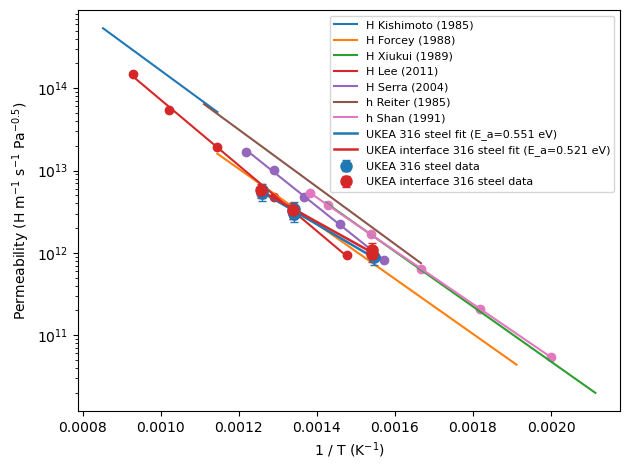

In [7]:
permeabilities = htm.permeabilities.filter(material="316l_steel").filter(isotope="h")
htm.plotting.plot(permeabilities)
ax = plt.gca()

for key, cfg in materials.items():
    T = data[key]["T"]
    Phi = data[key]["Phi"]
    invT_nom = 1.0 / unp.nominal_values(T)
    Phi_nom = unp.nominal_values(Phi)
    Phi_std = unp.std_devs(Phi)

    ax.errorbar(
        invT_nom, Phi_nom, yerr=Phi_std,
        fmt="o", markersize=8,
        color=cfg["color"], ecolor=cfg["color"],
        elinewidth=1, capsize=3,
        label=f"{cfg['label']} data",
    )
    f = fits[key]["Phi"]
    ax.plot(
        f["invT"], f["y"],
        "-", color=cfg["color"], linewidth=1.8,
        label=f"{cfg['label']} fit (E_a={f['E_a']:.3f} eV)",
    )

ax.set_yscale("log")
ax.set_xlabel("1 / T (K$^{-1}$)")
ax.set_ylabel("Permeability (H m$^{-1}$ s$^{-1}$ Pa$^{-0.5}$)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figs/UKEA_vs_UKEA_interface_permeability.pdf", bbox_inches="tight")
plt.show()

## Arrhenius fit summary

In [8]:
rows = []
for key, cfg in materials.items():
    rows.append({
        "Material": cfg["label"],
        "D_0 (m^2/s)": fits[key]["D"]["y0"],
        "E_D (eV)": fits[key]["D"]["E_a"],
        "Phi_0 (H m^-1 s^-1 Pa^-0.5)": fits[key]["Phi"]["y0"],
        "E_Phi (eV)": fits[key]["Phi"]["E_a"],
    })
summary = pd.DataFrame(rows)
summary

,Material,D_0 (m^2/s),E_D (eV),Phi_0 (H m^-1 s^-1 Pa^-0.5),E_Phi (eV)
0,UKEA 316 steel,55554.266419,2.165293,1.712705e+16,0.550815
1,UKEA interface 316 steel,3800.224662,1.988736,1.135102e+16,0.521383
